In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

torch.__version__

'2.10.0'

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Parameter definitions can be gotten from https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST

100.0%
100.0%
100.0%
100.0%


In [8]:
# We unpack the tuple to inspect the data
# The pixels stand for the numeric (tensor) representation of the clothing item
pixels, category = train_data[0]
pixels

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [ ]:
# 9 is the category of above image, could be a shoe, who knows
category

9

In [10]:
pixels.shape

torch.Size([1, 28, 28])

The shape suggests that the height of the image is 28 pixels, the width is also 28 pixels, and the color channels 1.
[color_channels = 1, height = 28, width = 28]
Color channels is kind of like the color that the image has, be it a greyscale image, or colored image with 3 as it's color scale representing RGB

In [11]:
# Now we check how many samples exist
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

We have 60,000 training samples and 10,000 testing samples

In [13]:
# Now we check the names of the targets using .classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Since train_data.classes is a list, we can see what clothing types are in the first 10 images.
Just for fun

In [26]:
for i in range(10):
    pixels, category = train_data[i]
    print(train_data.classes[category])

Ankle boot
T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal


Clothing Shape {torch.Size([1, 28, 28])}


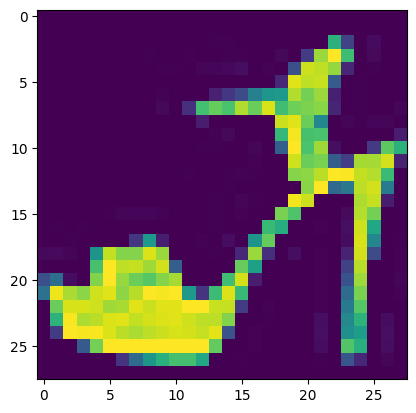

In [28]:
# Visualize
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze())

Looks like the first item is actually a type of shoe.
matplotlib will take in a 2d shape to make a plot, but as our tensor is 3d([1, 28, 28]), we use .squeeze
This basically removes an dimension that has a size of exactly 1, and that would remove our greyscale color, thus why we're having this neon one.

Clothing Shape {torch.Size([1, 28, 28])}


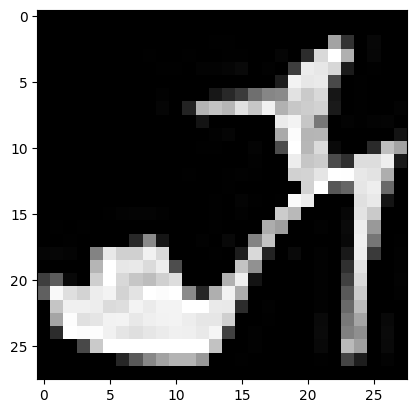

In [27]:
# Visualize again
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze(), cmap='grey')